In [64]:
import pathlib
import jupedsim as jps
import pedpy
from numpy.random import normal  # normal distribution of free movement speed
from shapely import Polygon

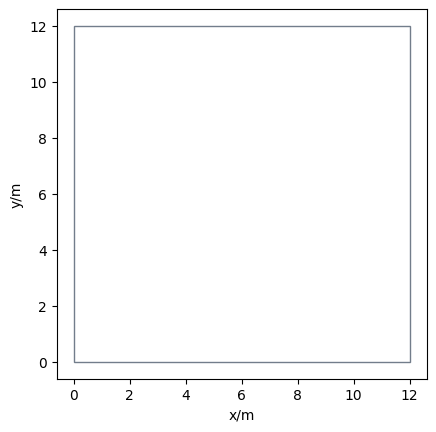

In [65]:
area = Polygon([(0, 0), (12, 0), (12, 12), (0, 12)])
walkable_area = pedpy.WalkableArea(area)
pedpy.plot_walkable_area(walkable_area=walkable_area).set_aspect("equal")

In [66]:
spawning_area = Polygon([(0, 0), (6, 0), (6, 2), (0, 2)])
num_agents = 20
pos_in_spawning_area = jps.distributions.distribute_by_number(
    polygon=spawning_area,
    number_of_agents=num_agents,
    distance_to_agents=0.4,
    distance_to_polygon=0.2,
    seed=1,
)
exit_area = Polygon([(10, 11), (12, 11), (12, 12), (10, 12)])

In [67]:
def plot_simulation_configuration(
    walkable_area, spawning_area, starting_positions, exit_area
):
    axes = pedpy.plot_walkable_area(walkable_area=walkable_area)
    axes.fill(*spawning_area.exterior.xy, color="lightgrey")
    axes.fill(*exit_area.exterior.xy, color="indianred")
    axes.scatter(*zip(*starting_positions))
    axes.set_xlabel("x/m")
    axes.set_ylabel("y/m")
    axes.set_aspect("equal")

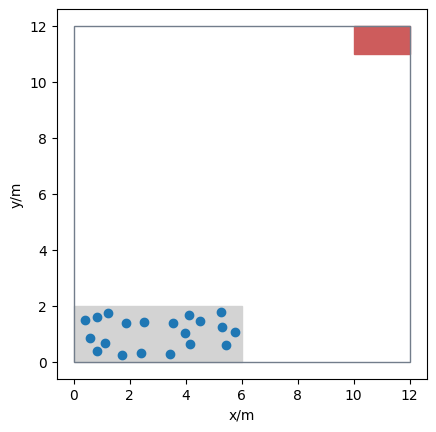

In [68]:
plot_simulation_configuration(
    walkable_area, spawning_area, pos_in_spawning_area, exit_area
)

In [69]:
trajectory_file = "corner.sqlite"  # output file
simulation = jps.Simulation(
    model=jps.AnticipationVelocityModel(),
    geometry=area,
    trajectory_writer=jps.SqliteTrajectoryWriter(
        output_file=pathlib.Path(trajectory_file)
    ),
)

In [70]:
exit_id = simulation.add_exit_stage(exit_area.exterior.coords[:-1])
journey = jps.JourneyDescription([exit_id])
journey_id = simulation.add_journey(journey)

In [71]:
import random

v_distribution = normal(1.34, 0.05, num_agents)

for pos, v0 in zip(pos_in_spawning_area, v_distribution):
    simulation.add_agent(
        jps.AnticipationVelocityModelAgentParameters(
            journey_id=journey_id,
            stage_id=exit_id,
            position=pos,
            desired_speed=v0,
            time_gap=random.uniform(0.0, 2.0)
        )
    )

while simulation.agent_count() > 0:
    simulation.iterate()

In [72]:
from jupedsim.internal.notebook_utils import animate, read_sqlite_file

trajectory_data, walkable_area = read_sqlite_file(trajectory_file)
animate(trajectory_data, walkable_area, every_nth_frame=5)